# VR Chinese OCR — Real-World Image Evaluation

**Course:** Deep Learning for Media (MPATE-GE 2039 / DM-GY 9103)  
**Task:** Real-world VR capture evaluation  
**Question:** How do OCR models perform on actual images captured in a VR environment?

### Key difference from `analysis_final`
The synthetic test set used artificial VR-simulated perturbations applied to CASIA-HWDB images.  
This notebook evaluates the same 5 models on **real VR captures** — photos taken directly inside a VR headset.  
Ground truth is the folder name (the target hanzi character).

### Models compared
| Model | Type |
|---|---|
| ANCHOR | VGG-like CNN trained on CASIA handwriting |
| PaddleOCR | Baidu production OCR system |
| EasyOCR | CRAFT + CRNN open-source |
| CnOCR | Lightweight Chinese OCR |
| Apple Vision | macOS on-device OCR (VNRecognizeTextRequest) |

### Dataset
Real VR captures organized into per-character folders.  
14 Chinese characters, 151 total images (unbalanced — 山 has 73, several characters have only 1).

## 1. Setup

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter
from sklearn.metrics import confusion_matrix

from evaluation.metrics import evaluate
from evaluation.utils import print_results_table

VR_DIR  = Path("../vr_test_images")
OUT_DIR = "../outputs"
os.makedirs(OUT_DIR, exist_ok=True)

# CJK-capable font so Chinese characters render correctly
_CJK_FONTS = ["Hiragino Sans GB", "Arial Unicode MS", "PingFang SC", "Heiti SC", "STHeiti"]
_available_fonts = {f.name for f in fm.fontManager.ttflist}
for _f in _CJK_FONTS:
    if _f in _available_fonts:
        matplotlib.rcParams["font.family"] = _f
        print(f"CJK font set: {_f}")
        break

CJK font set: Hiragino Sans GB


## 2. Load VR Test Images

In [2]:
MAX_SIDE = 640  # VR screenshots are ~2890x1682 — resize for inference speed

images, labels, paths = [], [], []

for char_dir in sorted(VR_DIR.iterdir()):
    if not char_dir.is_dir():
        continue
    char = char_dir.name
    for img_path in sorted(char_dir.glob("*.png")):
        img = Image.open(img_path).convert("RGB")
        w, h = img.size
        if max(w, h) > MAX_SIDE:
            scale = MAX_SIDE / max(w, h)
            img = img.resize((int(w * scale), int(h * scale)), Image.LANCZOS)
        images.append(np.array(img, dtype=np.uint8))
        labels.append(char)
        paths.append(img_path)

# Object arrays — same format as X_test / y_test in analysis_final
X_vr = np.empty(len(images), dtype=object)
for i, img in enumerate(images):
    X_vr[i] = img
y_vr = np.array(labels, dtype=object)

print(f"Total images : {len(y_vr)}")
print(f"Image size   : {images[0].shape} (resized from ~2890x1682 VR captures)")
print(f"Characters   : {sorted(set(labels))}")
print(f"Unique chars : {len(set(labels))}")

Total images : 151
Image size   : (372, 640, 3) (resized from ~2890x1682 VR captures)
Characters   : ['一', '三', '上', '了', '人', '力', '十', '土', '大', '山', '心', '月', '火', '犬']
Unique chars : 14


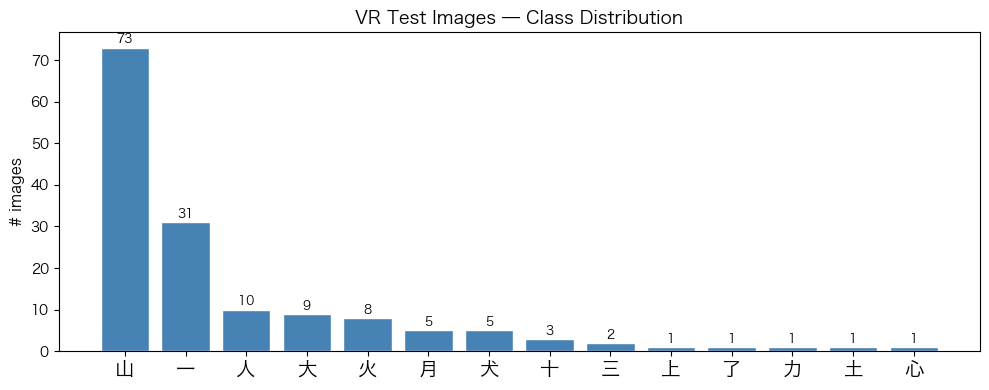

In [3]:
# Class distribution — important: highly imbalanced
counts = Counter(labels)
chars_sorted = sorted(counts, key=lambda c: -counts[c])

fig, ax = plt.subplots(figsize=(10, 4))
bars = ax.bar(
    range(len(chars_sorted)),
    [counts[c] for c in chars_sorted],
    color="steelblue", edgecolor="white",
)
ax.set_xticks(range(len(chars_sorted)))
ax.set_xticklabels(chars_sorted, fontsize=14)
ax.set_ylabel("# images", fontsize=11)
ax.set_title("VR Test Images — Class Distribution", fontsize=13, fontweight="bold")
for bar, c in zip(bars, chars_sorted):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            str(counts[c]), ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/vr_fig_class_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

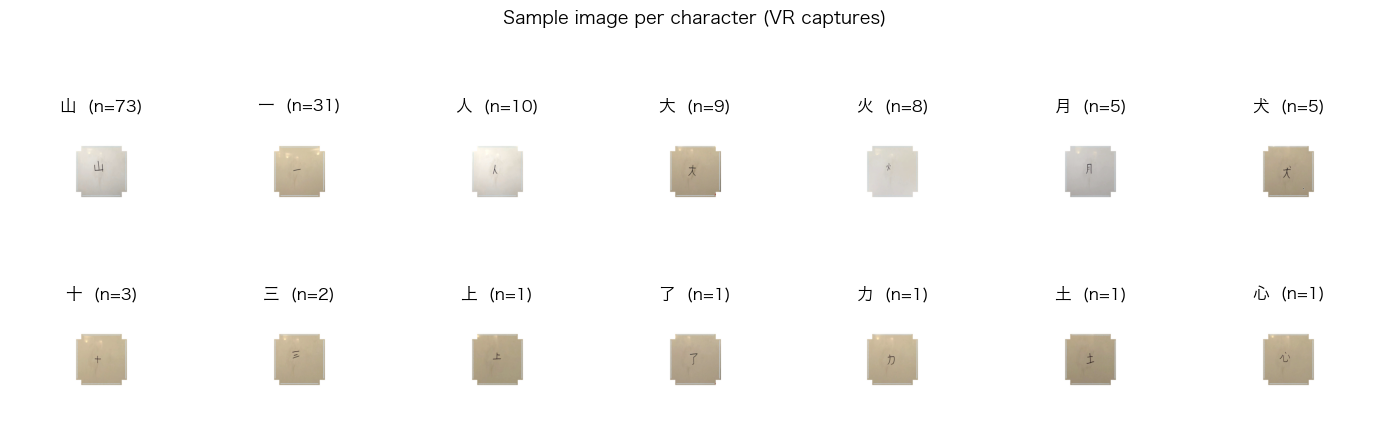

In [4]:
# Show one sample image per character
n_chars = len(chars_sorted)
fig, axes = plt.subplots(2, 7, figsize=(14, 5))
axes = axes.flat
for ax, char in zip(axes, chars_sorted):
    idx = next(i for i, l in enumerate(labels) if l == char)
    ax.imshow(images[idx])
    ax.set_title(f"{char}  (n={counts[char]})", fontsize=12)
    ax.axis("off")
# hide any leftover axes
for ax in list(axes)[n_chars:]:
    ax.set_visible(False)
fig.suptitle("Sample image per character (VR captures)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/vr_fig_sample_images.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Run Inference (cached)

Each model's predictions are cached to `outputs/vr_preds_*.npy`.  
Delete the cache file and re-run to force fresh inference.

In [5]:
# ANCHOR
ANCHOR_CACHE = f"{OUT_DIR}/vr_preds_anchor.npy"

if os.path.exists(ANCHOR_CACHE):
    preds_anchor = np.load(ANCHOR_CACHE, allow_pickle=True)
    print(f"[ANCHOR] Loaded cached predictions: {len(preds_anchor)} samples")
else:
    from models.anchor_inference import run_anchor
    preds_anchor = run_anchor(X_vr, show_progress=True)
    np.save(ANCHOR_CACHE, preds_anchor)
    print(f"[ANCHOR] Saved to {ANCHOR_CACHE}")

[ANCHOR] Loaded cached predictions: 151 samples


In [6]:
# PaddleOCR
PADDLE_CACHE = f"{OUT_DIR}/vr_preds_paddleocr.npy"

if os.path.exists(PADDLE_CACHE):
    preds_paddle = np.load(PADDLE_CACHE, allow_pickle=True)
    print(f"[PaddleOCR] Loaded cached predictions: {len(preds_paddle)} samples")
else:
    from models.paddleocr_inference import run_paddleocr
    preds_paddle = run_paddleocr(X_vr, show_progress=True)
    np.save(PADDLE_CACHE, preds_paddle)
    print(f"[PaddleOCR] Saved to {PADDLE_CACHE}")

[PaddleOCR] Loaded cached predictions: 151 samples


In [7]:
# EasyOCR
EASY_CACHE = f"{OUT_DIR}/vr_preds_easyocr.npy"

if os.path.exists(EASY_CACHE):
    preds_easy = np.load(EASY_CACHE, allow_pickle=True)
    print(f"[EasyOCR] Loaded cached predictions: {len(preds_easy)} samples")
else:
    from models.easyocr_inference import run_easyocr
    preds_easy = run_easyocr(X_vr, show_progress=True)
    np.save(EASY_CACHE, preds_easy)
    print(f"[EasyOCR] Saved to {EASY_CACHE}")

[EasyOCR] Loaded cached predictions: 151 samples


In [8]:
# CnOCR
CNOCR_CACHE = f"{OUT_DIR}/vr_preds_cnocr.npy"

if os.path.exists(CNOCR_CACHE):
    preds_cnocr = np.load(CNOCR_CACHE, allow_pickle=True)
    print(f"[CnOCR] Loaded cached predictions: {len(preds_cnocr)} samples")
else:
    from models.cnocr_inference import run_cnocr
    preds_cnocr = run_cnocr(X_vr, show_progress=True)
    np.save(CNOCR_CACHE, preds_cnocr)
    print(f"[CnOCR] Saved to {CNOCR_CACHE}")

[CnOCR] Loaded cached predictions: 151 samples


In [9]:
# Apple Vision
AV_CACHE = f"{OUT_DIR}/vr_preds_applevision.npy"

if os.path.exists(AV_CACHE):
    preds_av = np.load(AV_CACHE, allow_pickle=True)
    print(f"[Apple Vision] Loaded cached predictions: {len(preds_av)} samples")
else:
    try:
        import subprocess
        subprocess.run(
            [sys.executable, "-m", "pip", "install", "pyobjc-framework-Vision", "-q"],
            check=True,
        )
        from models.apple_vision_inference import run_apple_vision
        preds_av = run_apple_vision(X_vr, show_progress=True)
        np.save(AV_CACHE, preds_av)
        print(f"[Apple Vision] Saved to {AV_CACHE}")
    except Exception as e:
        print(f"[Apple Vision] Not available: {e}")
        preds_av = None

# Collect all predictions
preds = {
    "ANCHOR":    preds_anchor,
    "PaddleOCR": preds_paddle,
    "EasyOCR":   preds_easy,
    "CnOCR":     preds_cnocr,
}
if preds_av is not None:
    preds["Apple Vision"] = preds_av

print(f"\nModels ready: {list(preds.keys())}")

[Apple Vision] Loaded cached predictions: 151 samples

Models ready: ['ANCHOR', 'PaddleOCR', 'EasyOCR', 'CnOCR', 'Apple Vision']


## 4. Evaluate All Models

In [10]:
# Overall metrics (no perturbation breakdown — these are real VR images)
results_dict = {
    name: evaluate(pred, y_vr)
    for name, pred in preds.items()
}

# Per-character breakdown: reuse evaluate() with characters as 'perturbation types'
results_per_char = {
    name: evaluate(pred, y_vr, perturbation_types=y_vr)
    for name, pred in preds.items()
}

print(f"Models evaluated: {list(results_dict.keys())}")

Models evaluated: ['ANCHOR', 'PaddleOCR', 'EasyOCR', 'CnOCR', 'Apple Vision']


## 5. Performance Tables

In [11]:
print("=" * 70)
print("OVERALL METRICS  (VR real captures, 14 chars, 151 images)")
print("=" * 70)
print_results_table(results_dict)

OVERALL METRICS  (VR real captures, 14 chars, 151 images)
Model          Accuracy      CER   Precision   Recall       F1
──────────────────────────────────────────────────────────────
ANCHOR             0.0%    1.000        0.0%     0.0%     0.0%
PaddleOCR         34.4%    0.656       40.0%    28.7%    32.0%
EasyOCR            1.3%    0.987       13.3%     8.0%     8.9%
CnOCR             59.6%    0.404       38.9%    30.9%    33.5%
Apple Vision      23.2%    0.768       46.3%    30.0%    33.9%


In [12]:
# Per-character accuracy table
all_chars = sorted(set(y_vr.tolist()))

# Header
col_w = 12
model_names = list(results_per_char.keys())
header = f"{'Char':<6}  {'n':>4}  " + "".join(f"{m:>{col_w}}" for m in model_names)
print(header)
print("-" * len(header))

for char in all_chars:
    n = sum(1 for l in labels if l == char)
    row = f"{char:<6}  {n:>4}  "
    for name in model_names:
        bp = results_per_char[name].get("by_perturbation", {})
        acc = bp.get(char, {}).get("exact_match", float("nan"))
        row += f"{acc*100:>{col_w}.1f}%"[:-1] + "%" if not (acc != acc) else f"{'N/A':>{col_w}}"
    print(row)

Char       n        ANCHOR   PaddleOCR     EasyOCR       CnOCRApple Vision
--------------------------------------------------------------------------
一         31           0.0%         0.0%         0.0%         0.0%         0.0%
三          2           0.0%        50.0%         0.0%         0.0%        50.0%
上          1           0.0%       100.0%         0.0%       100.0%       100.0%
了          1           0.0%       100.0%         0.0%         0.0%         0.0%
人         10           0.0%        20.0%         0.0%        50.0%        20.0%
力          1           0.0%       100.0%       100.0%         0.0%       100.0%
十          3           0.0%         0.0%         0.0%        66.7%         0.0%
土          1           0.0%       100.0%         0.0%         0.0%       100.0%
大          9           0.0%        77.8%         0.0%        88.9%        44.4%
山         73           0.0%        37.0%         0.0%        90.4%        30.1%
心          1           0.0%       100.0%         0

## 6. Per-Character Accuracy Plot

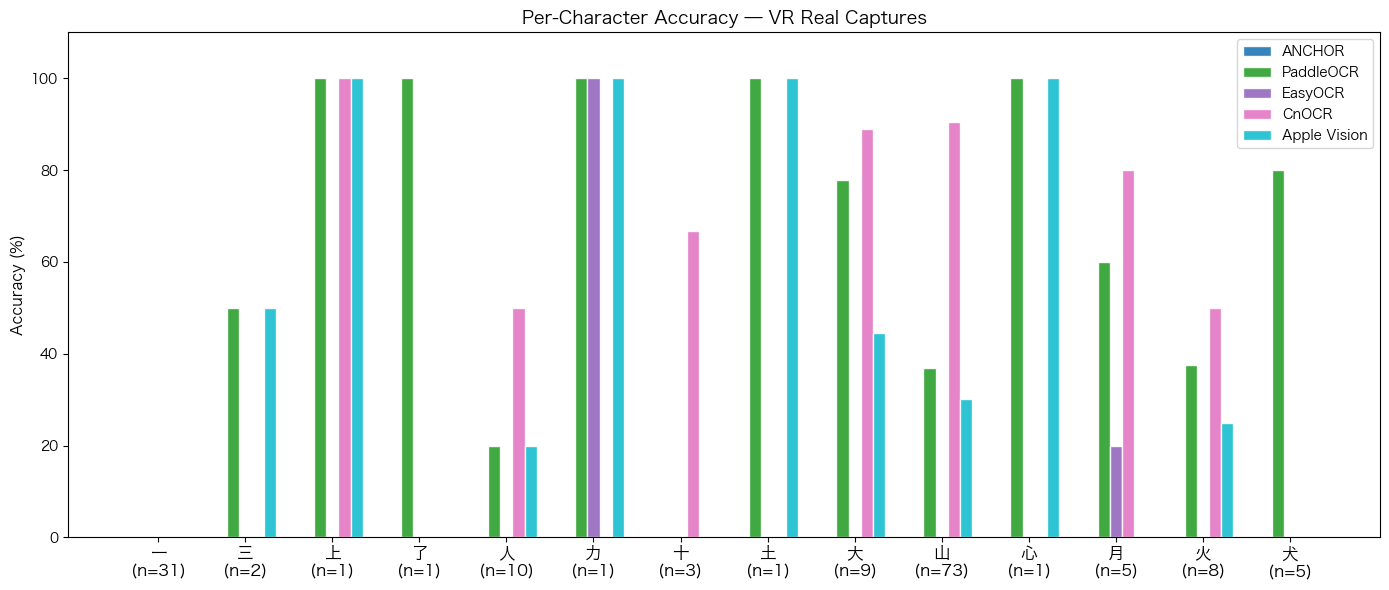

In [13]:
model_names = list(preds.keys())
n_models = len(model_names)
n_chars = len(all_chars)

# Color palette — one color per model
colors = plt.cm.tab10(np.linspace(0, 0.9, n_models))

bar_w = 0.7 / n_models
x = np.arange(n_chars)

fig, ax = plt.subplots(figsize=(14, 6))

for i, (name, color) in enumerate(zip(model_names, colors)):
    bp = results_per_char[name].get("by_perturbation", {})
    accs = [bp.get(c, {}).get("exact_match", 0.0) * 100 for c in all_chars]
    offset = (i - n_models / 2 + 0.5) * bar_w
    ax.bar(x + offset, accs, width=bar_w, label=name, color=color, alpha=0.9, edgecolor="white")

ax.set_xticks(x)
ax.set_xticklabels(
    [f"{c}\n(n={counts[c]})" for c in all_chars],
    fontsize=12,
)
ax.set_ylabel("Accuracy (%)", fontsize=11)
ax.set_ylim(0, 110)
ax.set_title("Per-Character Accuracy — VR Real Captures", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=10)
ax.axhline(y=0, color="black", linewidth=0.5)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/vr_fig_per_char_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

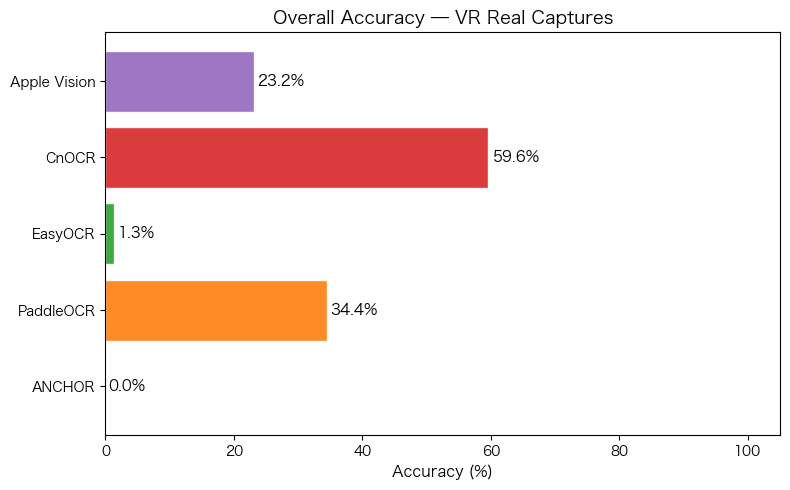

In [14]:
# Overall accuracy bar chart — easier comparison across models
fig, ax = plt.subplots(figsize=(8, 5))
accs_overall = [results_dict[m]["exact_match"] * 100 for m in model_names]
bars = ax.barh(
    model_names, accs_overall,
    color=[plt.cm.tab10(i / 10) for i in range(n_models)],
    edgecolor="white", alpha=0.9,
)
for bar, acc in zip(bars, accs_overall):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
            f"{acc:.1f}%", va="center", fontsize=11)
ax.set_xlim(0, 105)
ax.set_xlabel("Accuracy (%)", fontsize=11)
ax.set_title("Overall Accuracy — VR Real Captures", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/vr_fig_overall_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

## 7. Confusion Matrix

With only 14 characters we can show **all** of them (no need to filter top-N).  
Row-normalized: each row sums to 1, diagonal = correct recall per character.

In [15]:
def plot_vr_confusion(y_true, y_pred, model_name, save_path=None):
    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)

    chars = sorted(set(y_true.tolist()))
    # Map predictions outside known chars to "other"
    y_pred_mapped = np.where(np.isin(y_pred, chars), y_pred, "other")
    col_labels = chars + ["other"]

    cm = confusion_matrix(y_true, y_pred_mapped, labels=col_labels)
    cm = cm[:len(chars), :]  # keep only true-char rows

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_norm = np.where(row_sums > 0, cm / row_sums, 0.0)

    fig, ax = plt.subplots(figsize=(12, 9))
    sns.heatmap(
        cm_norm, annot=True, fmt=".2f",
        xticklabels=col_labels, yticklabels=chars,
        cmap="Blues", vmin=0, vmax=1,
        linewidths=0.4, linecolor="#e0e0e0", ax=ax,
    )
    ax.set_title(f"{model_name} — Confusion Matrix (VR captures)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Ground Truth", fontsize=10)
    ax.set_xlabel("Predicted", fontsize=10)
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=11)
    plt.setp(ax.get_yticklabels(), rotation=0, fontsize=11)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

print("Helper defined.")

Helper defined.


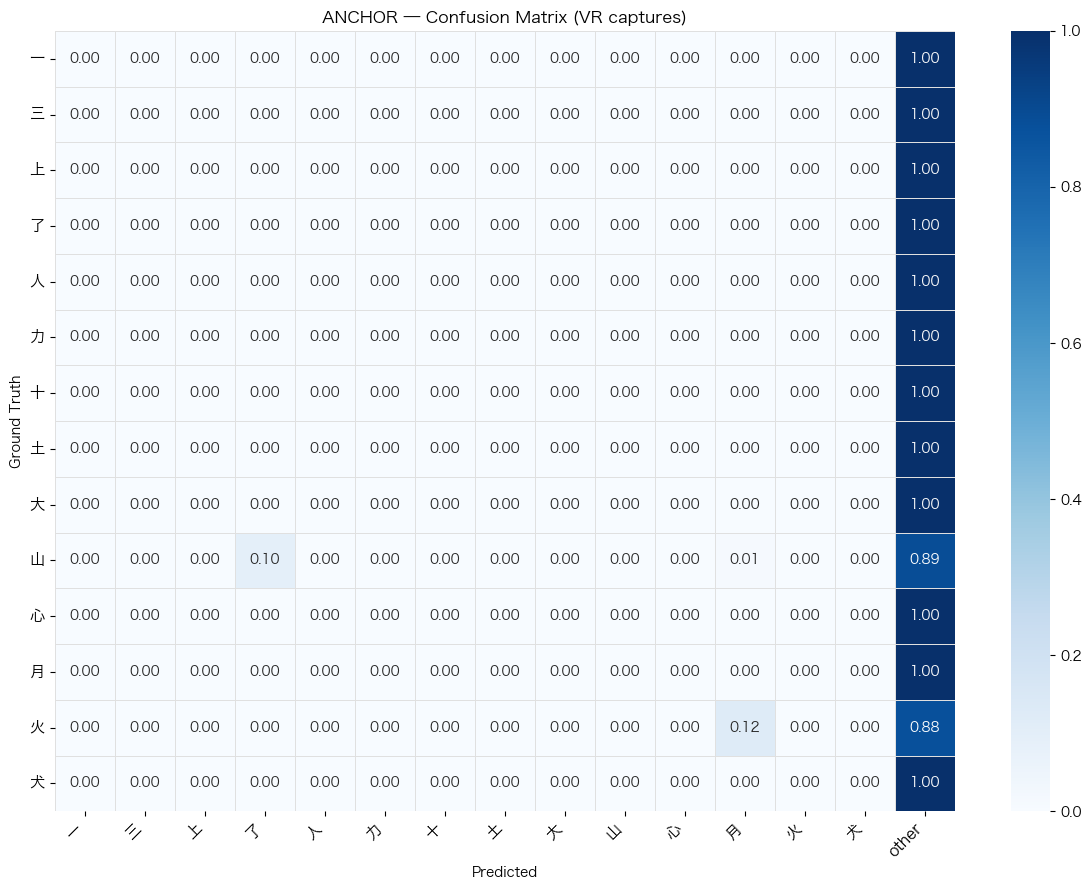

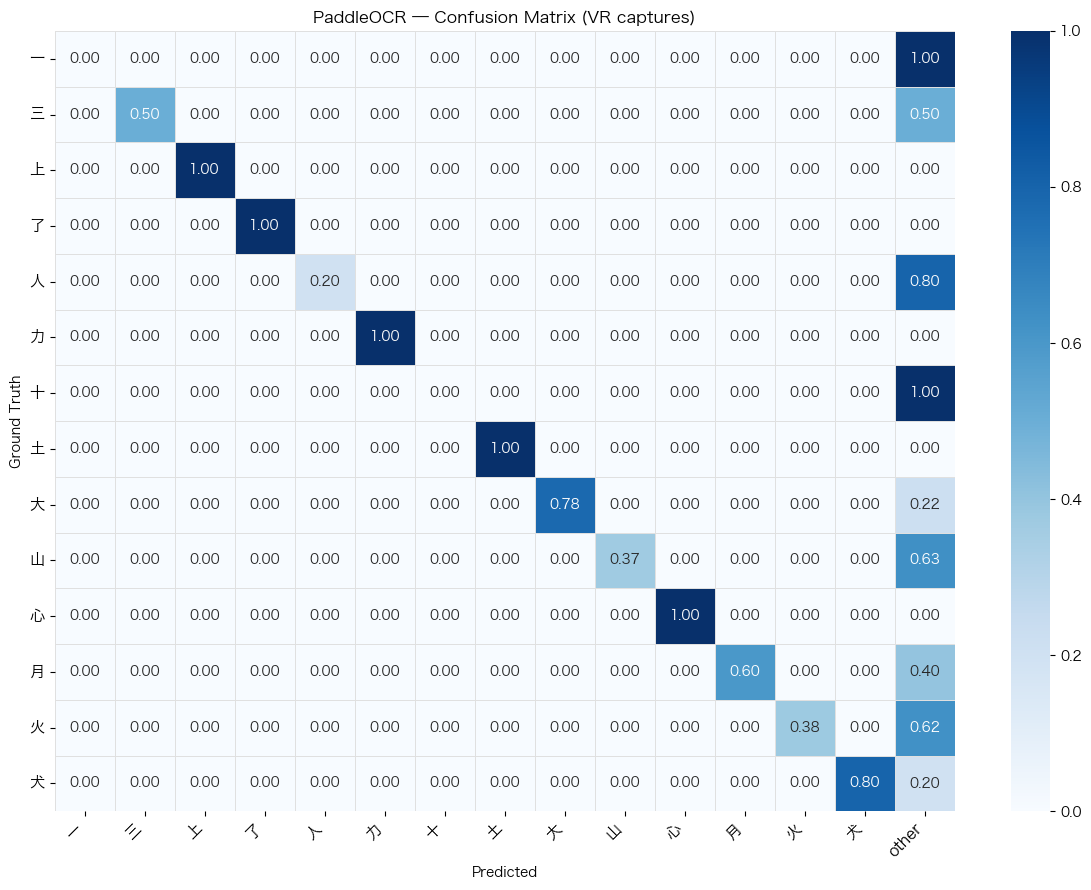

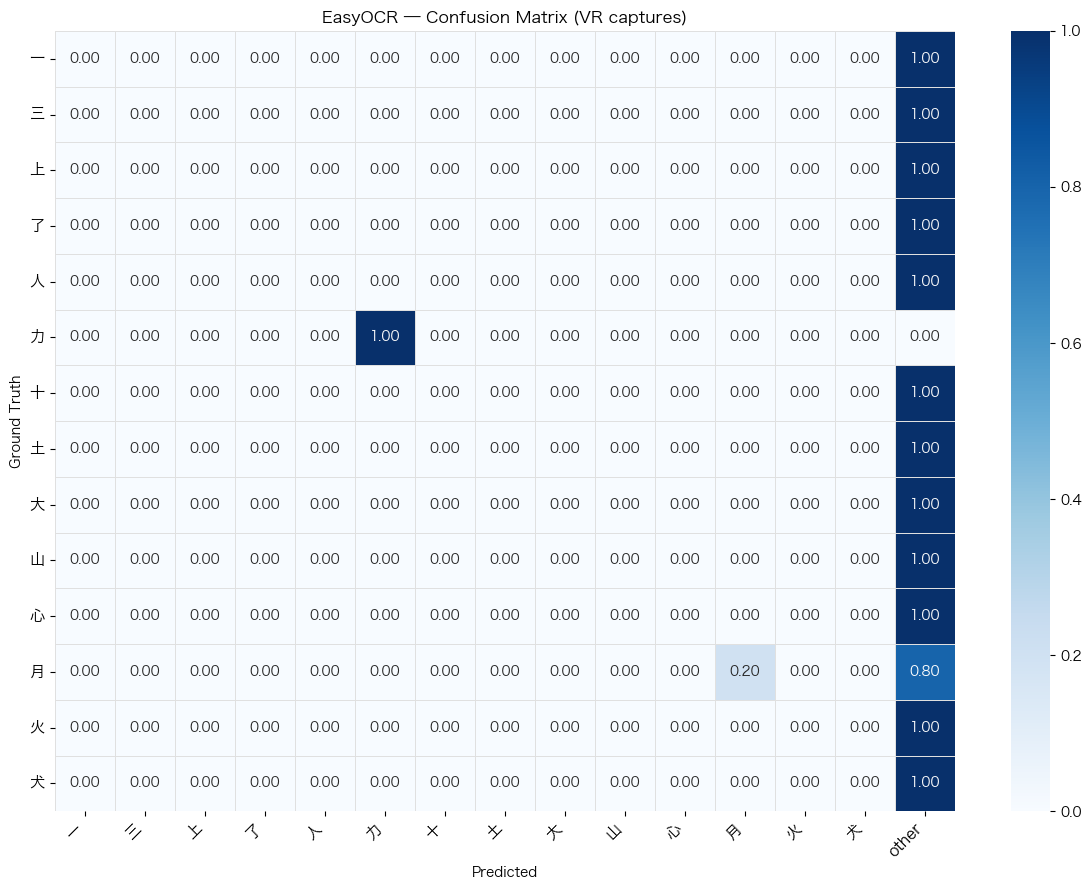

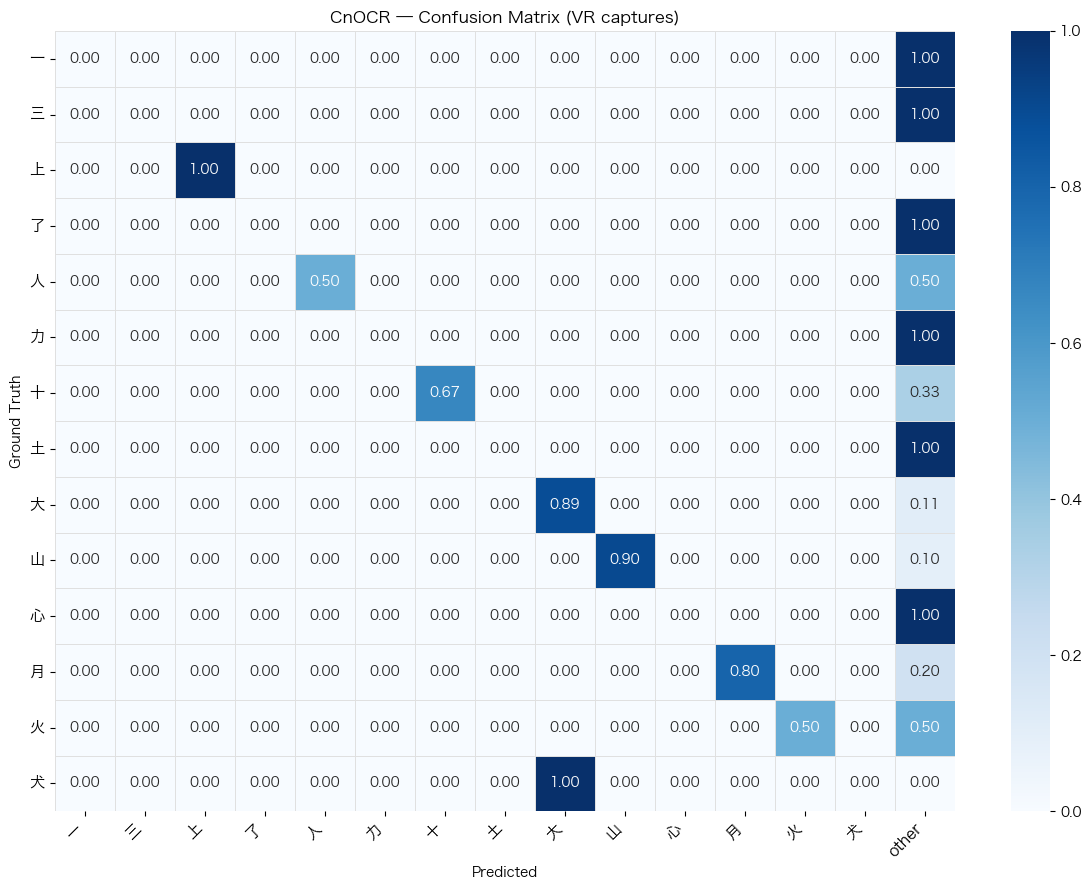

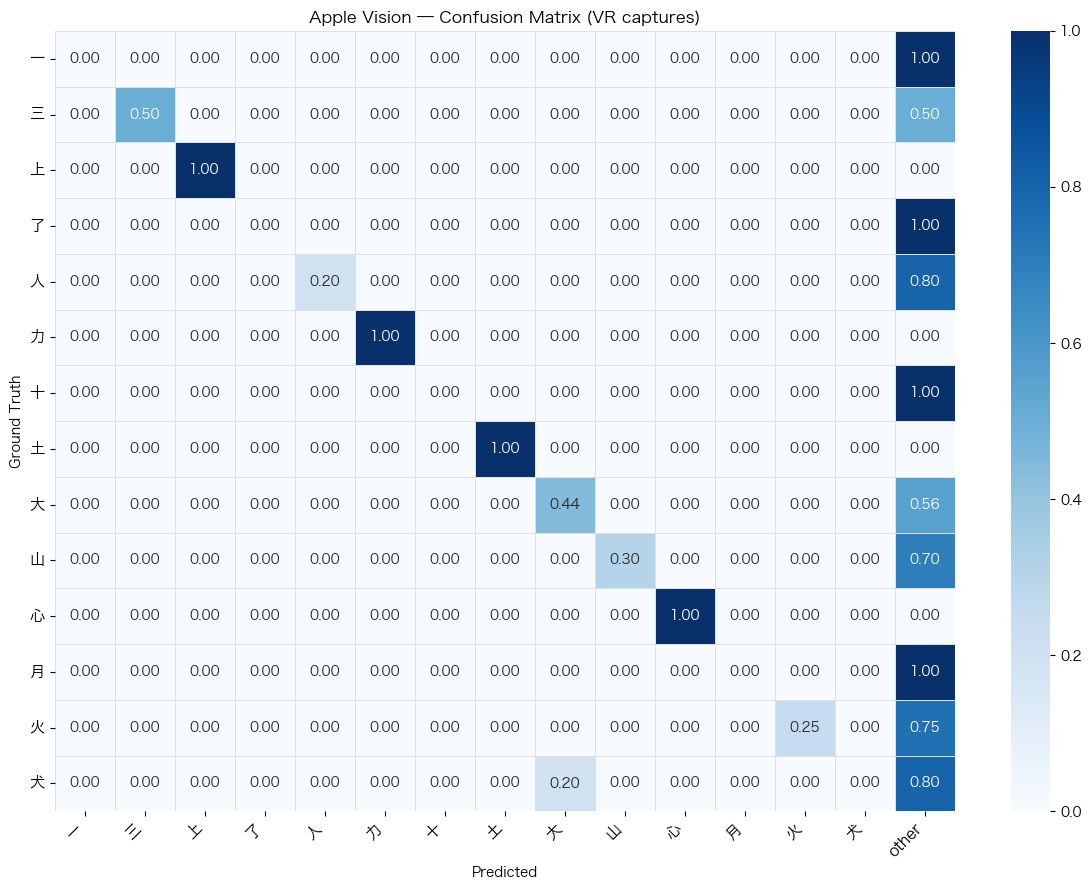

In [16]:
for name, pred in preds.items():
    safe_name = name.lower().replace(" ", "_")
    plot_vr_confusion(
        y_vr, pred,
        model_name=name,
        save_path=f"{OUT_DIR}/vr_fig_confusion_{safe_name}.png",
    )

## 8. Failure Analysis

In [17]:
# Failure overlap across all models
preds_arr = {name: np.asarray(pred, dtype=object) for name, pred in preds.items()}
y_arr = np.asarray(y_vr, dtype=object)

wrong_masks = {name: preds_arr[name] != y_arr for name in preds_arr}
all_wrong_mask = np.all(list(wrong_masks.values()), axis=0)
all_correct_mask = np.all([~m for m in wrong_masks.values()], axis=0)

print(f"Total samples   : {len(y_arr)}")
print(f"All models wrong: {all_wrong_mask.sum()} ({all_wrong_mask.mean()*100:.1f}%)")
print(f"All models right: {all_correct_mask.sum()} ({all_correct_mask.mean()*100:.1f}%)")
print()
for name in preds_arr:
    only_wrong = wrong_masks[name] & ~np.any(
        [wrong_masks[n] for n in preds_arr if n != name], axis=0
    )
    print(f"  Only {name} wrong: {only_wrong.sum()} ({only_wrong.mean()*100:.1f}%)")

Total samples   : 151
All models wrong: 50 (33.1%)
All models right: 0 (0.0%)

  Only ANCHOR wrong: 0 (0.0%)
  Only PaddleOCR wrong: 0 (0.0%)
  Only EasyOCR wrong: 0 (0.0%)
  Only CnOCR wrong: 0 (0.0%)
  Only Apple Vision wrong: 0 (0.0%)


In [18]:
# Show failure cases for each model (up to 12 images)
def show_vr_failures(X, y_true, y_pred, model_name, n=12, save_path=None):
    y_true = np.asarray(y_true, dtype=object)
    y_pred = np.asarray(y_pred, dtype=object)
    wrong_idx = np.where(y_true != y_pred)[0]

    if len(wrong_idx) == 0:
        print(f"{model_name}: No failures!")
        return

    show_idx = wrong_idx[:n]
    cols = min(6, len(show_idx))
    rows = (len(show_idx) + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 2.2, rows * 2.8))
    axes = np.array(axes).flat

    for ax, idx in zip(axes, show_idx):
        ax.imshow(X[idx])
        pred_str = str(y_pred[idx]) if str(y_pred[idx]).strip() else "(empty)"
        ax.set_title(f"GT: {y_true[idx]}\nPred: {pred_str}",
                     fontsize=10, color="red")
        ax.axis("off")

    for ax in list(axes)[len(show_idx):]:
        ax.set_visible(False)

    fig.suptitle(
        f"{model_name} — Failures ({len(wrong_idx)} total, showing {len(show_idx)})",
        fontsize=12, fontweight="bold",
    )
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.show()

print("Helper defined.")

Helper defined.


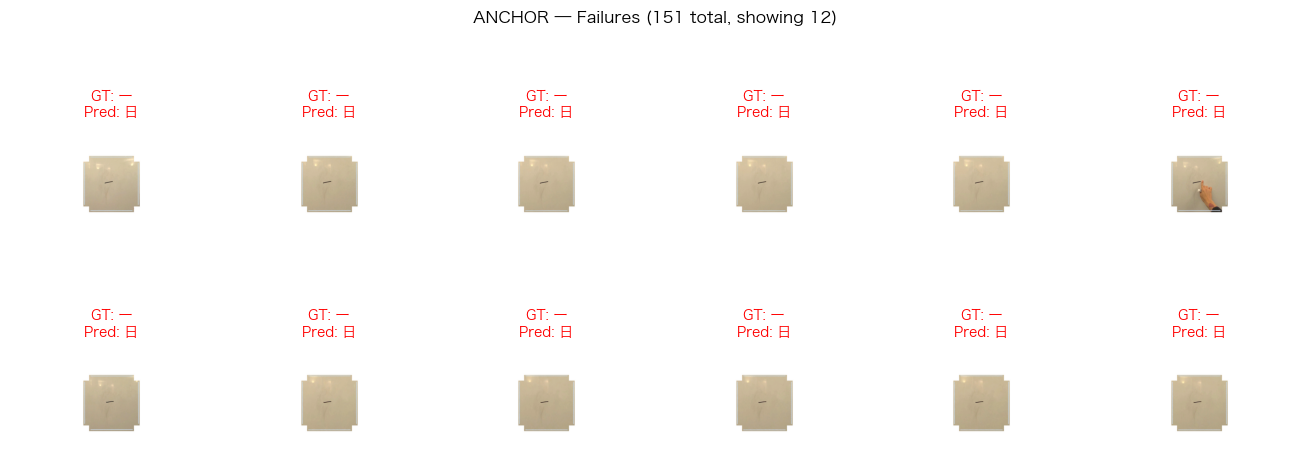

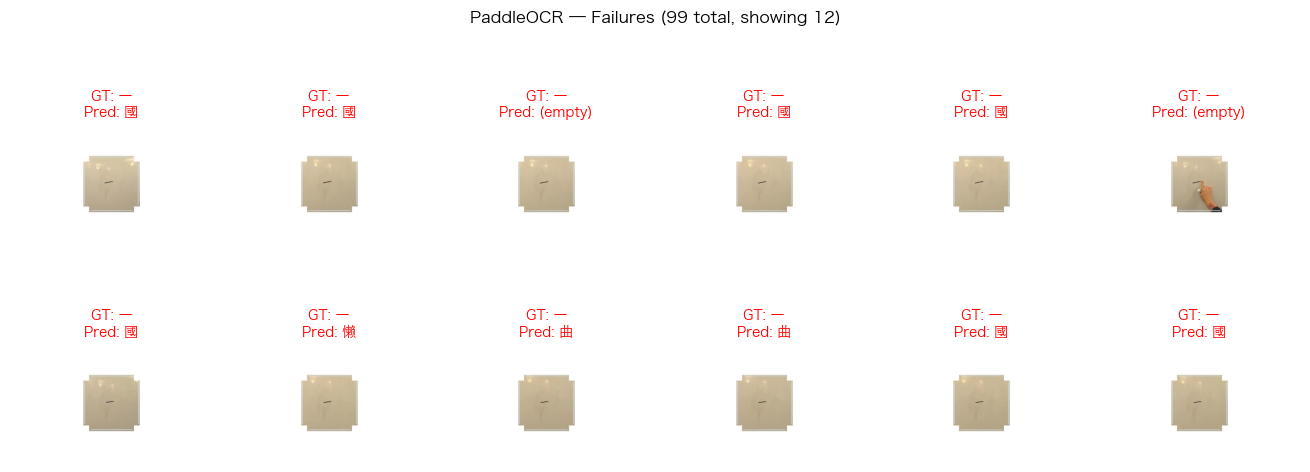

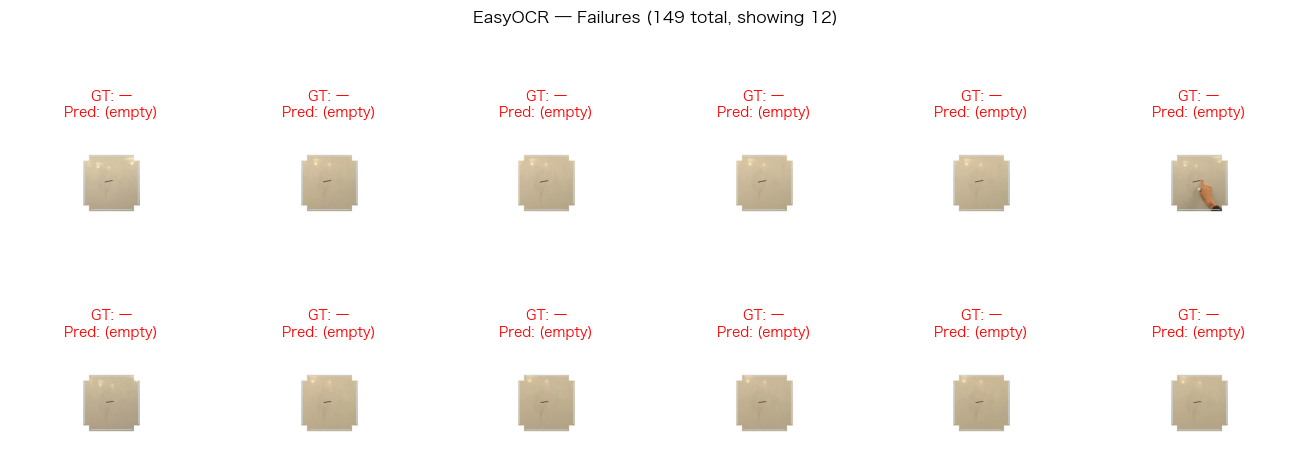

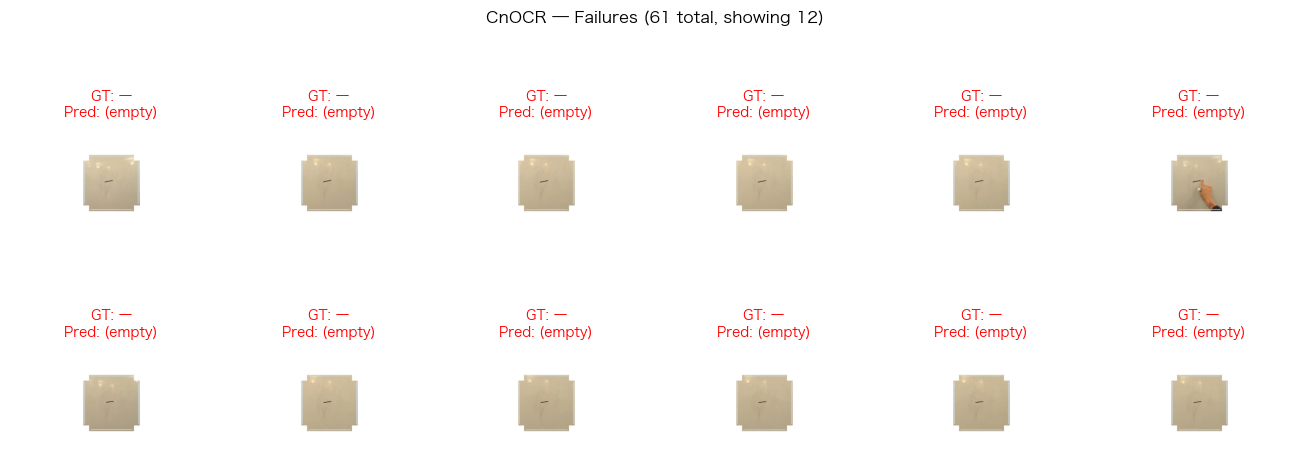

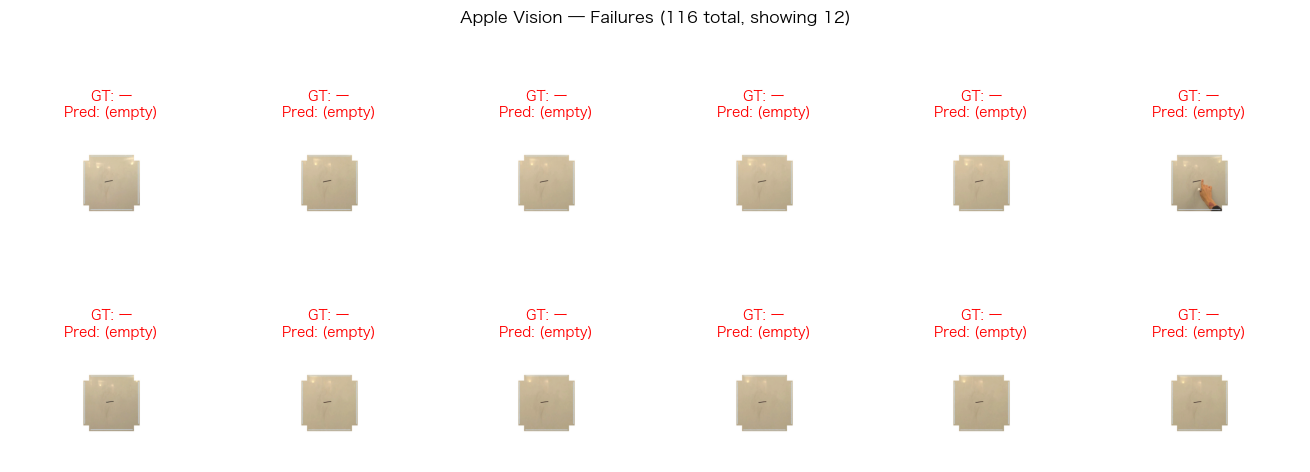

In [19]:
for name, pred in preds.items():
    safe_name = name.lower().replace(" ", "_")
    show_vr_failures(
        X_vr, y_vr, pred,
        model_name=name, n=12,
        save_path=f"{OUT_DIR}/vr_fig_failures_{safe_name}.png",
    )

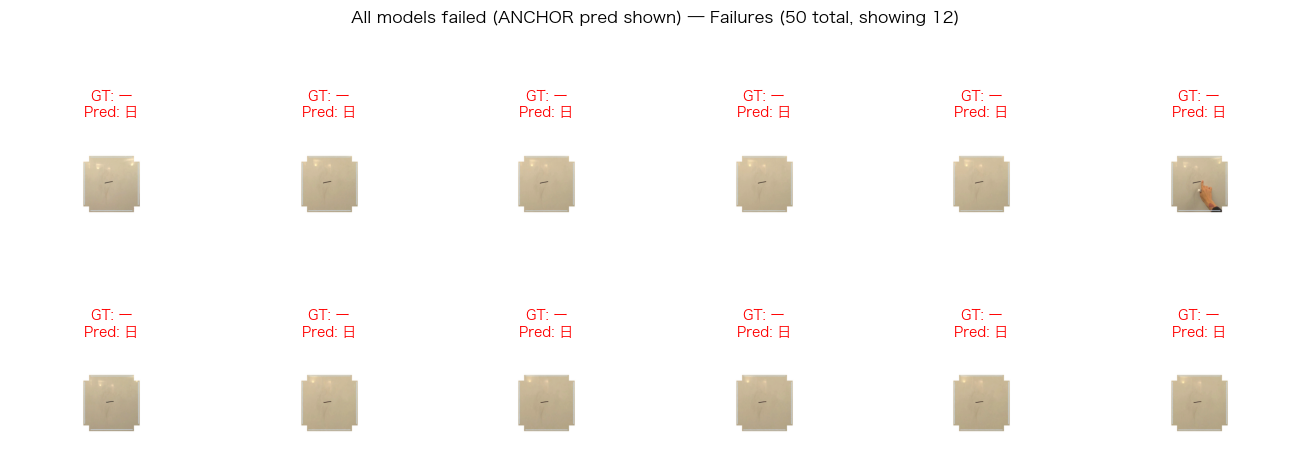

In [20]:
# Show images that ALL models fail on
if all_wrong_mask.sum() > 0:
    show_vr_failures(
        X_vr[all_wrong_mask], y_vr[all_wrong_mask],
        preds_arr["ANCHOR"][all_wrong_mask],
        model_name="All models failed (ANCHOR pred shown)",
        n=12,
        save_path=f"{OUT_DIR}/vr_fig_failures_all_wrong.png",
    )
else:
    print("No samples that all models fail on.")

## 9. Top Confused Character Pairs

In [21]:
for name, pred in preds.items():
    y_t = np.asarray(y_vr, dtype=object)
    y_p = np.asarray(pred, dtype=object)
    wrong = y_t != y_p
    pairs = Counter(zip(y_t[wrong], y_p[wrong]))
    top = pairs.most_common(8)
    print(f"\n{name} — top confused pairs:")
    print(f"  {'GT':>6}  {'Pred':>10}  Count")
    for (gt, pr), cnt in top:
        pred_str = str(pr).strip() or "(empty)"
        print(f"  {gt:>6}  {pred_str:>10}  {cnt}")


ANCHOR — top confused pairs:
      GT        Pred  Count
       山           日  32
       一           日  30
       山           口  29
       大           日  7
       山           了  7
       犬           日  5
       月           口  4
       火           口  4

PaddleOCR — top confused pairs:
      GT        Pred  Count
       山     (empty)  44
       一           國  15
       一     (empty)  7
       人     (empty)  5
       火     (empty)  4
       十     (empty)  3
       一           曲  2
       人           ©  2

EasyOCR — top confused pairs:
      GT        Pred  Count
       山     (empty)  73
       一     (empty)  31
       人     (empty)  10
       大     (empty)  9
       火     (empty)  8
       犬     (empty)  5
       月     (empty)  4
       十     (empty)  3

CnOCR — top confused pairs:
      GT        Pred  Count
       一     (empty)  31
       山     (empty)  7
       人     (empty)  5
       犬           大  5
       火     (empty)  4
       三           二  2
       了     (empty)  1
       力    

## 10. Qualitative: Model Predictions on Sample Images

Grid showing one image per character with the prediction from each model.

/var/folders/dt/g_vt1y3x4tj1_tjt1l6yhnfh0000gn/T/ipykernel_32786/1308967011.py:40: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Hiragino Sans GB.
  plt.tight_layout()
/var/folders/dt/g_vt1y3x4tj1_tjt1l6yhnfh0000gn/T/ipykernel_32786/1308967011.py:41: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Hiragino Sans GB.
  plt.savefig(f"{OUT_DIR}/vr_fig_predictions_grid.png", dpi=150, bbox_inches="tight")


/opt/miniconda3/envs/vr-ocr-eval/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8709 (\N{EMPTY SET}) missing from font(s) Hiragino Sans GB.
  fig.canvas.print_figure(bytes_io, **kw)


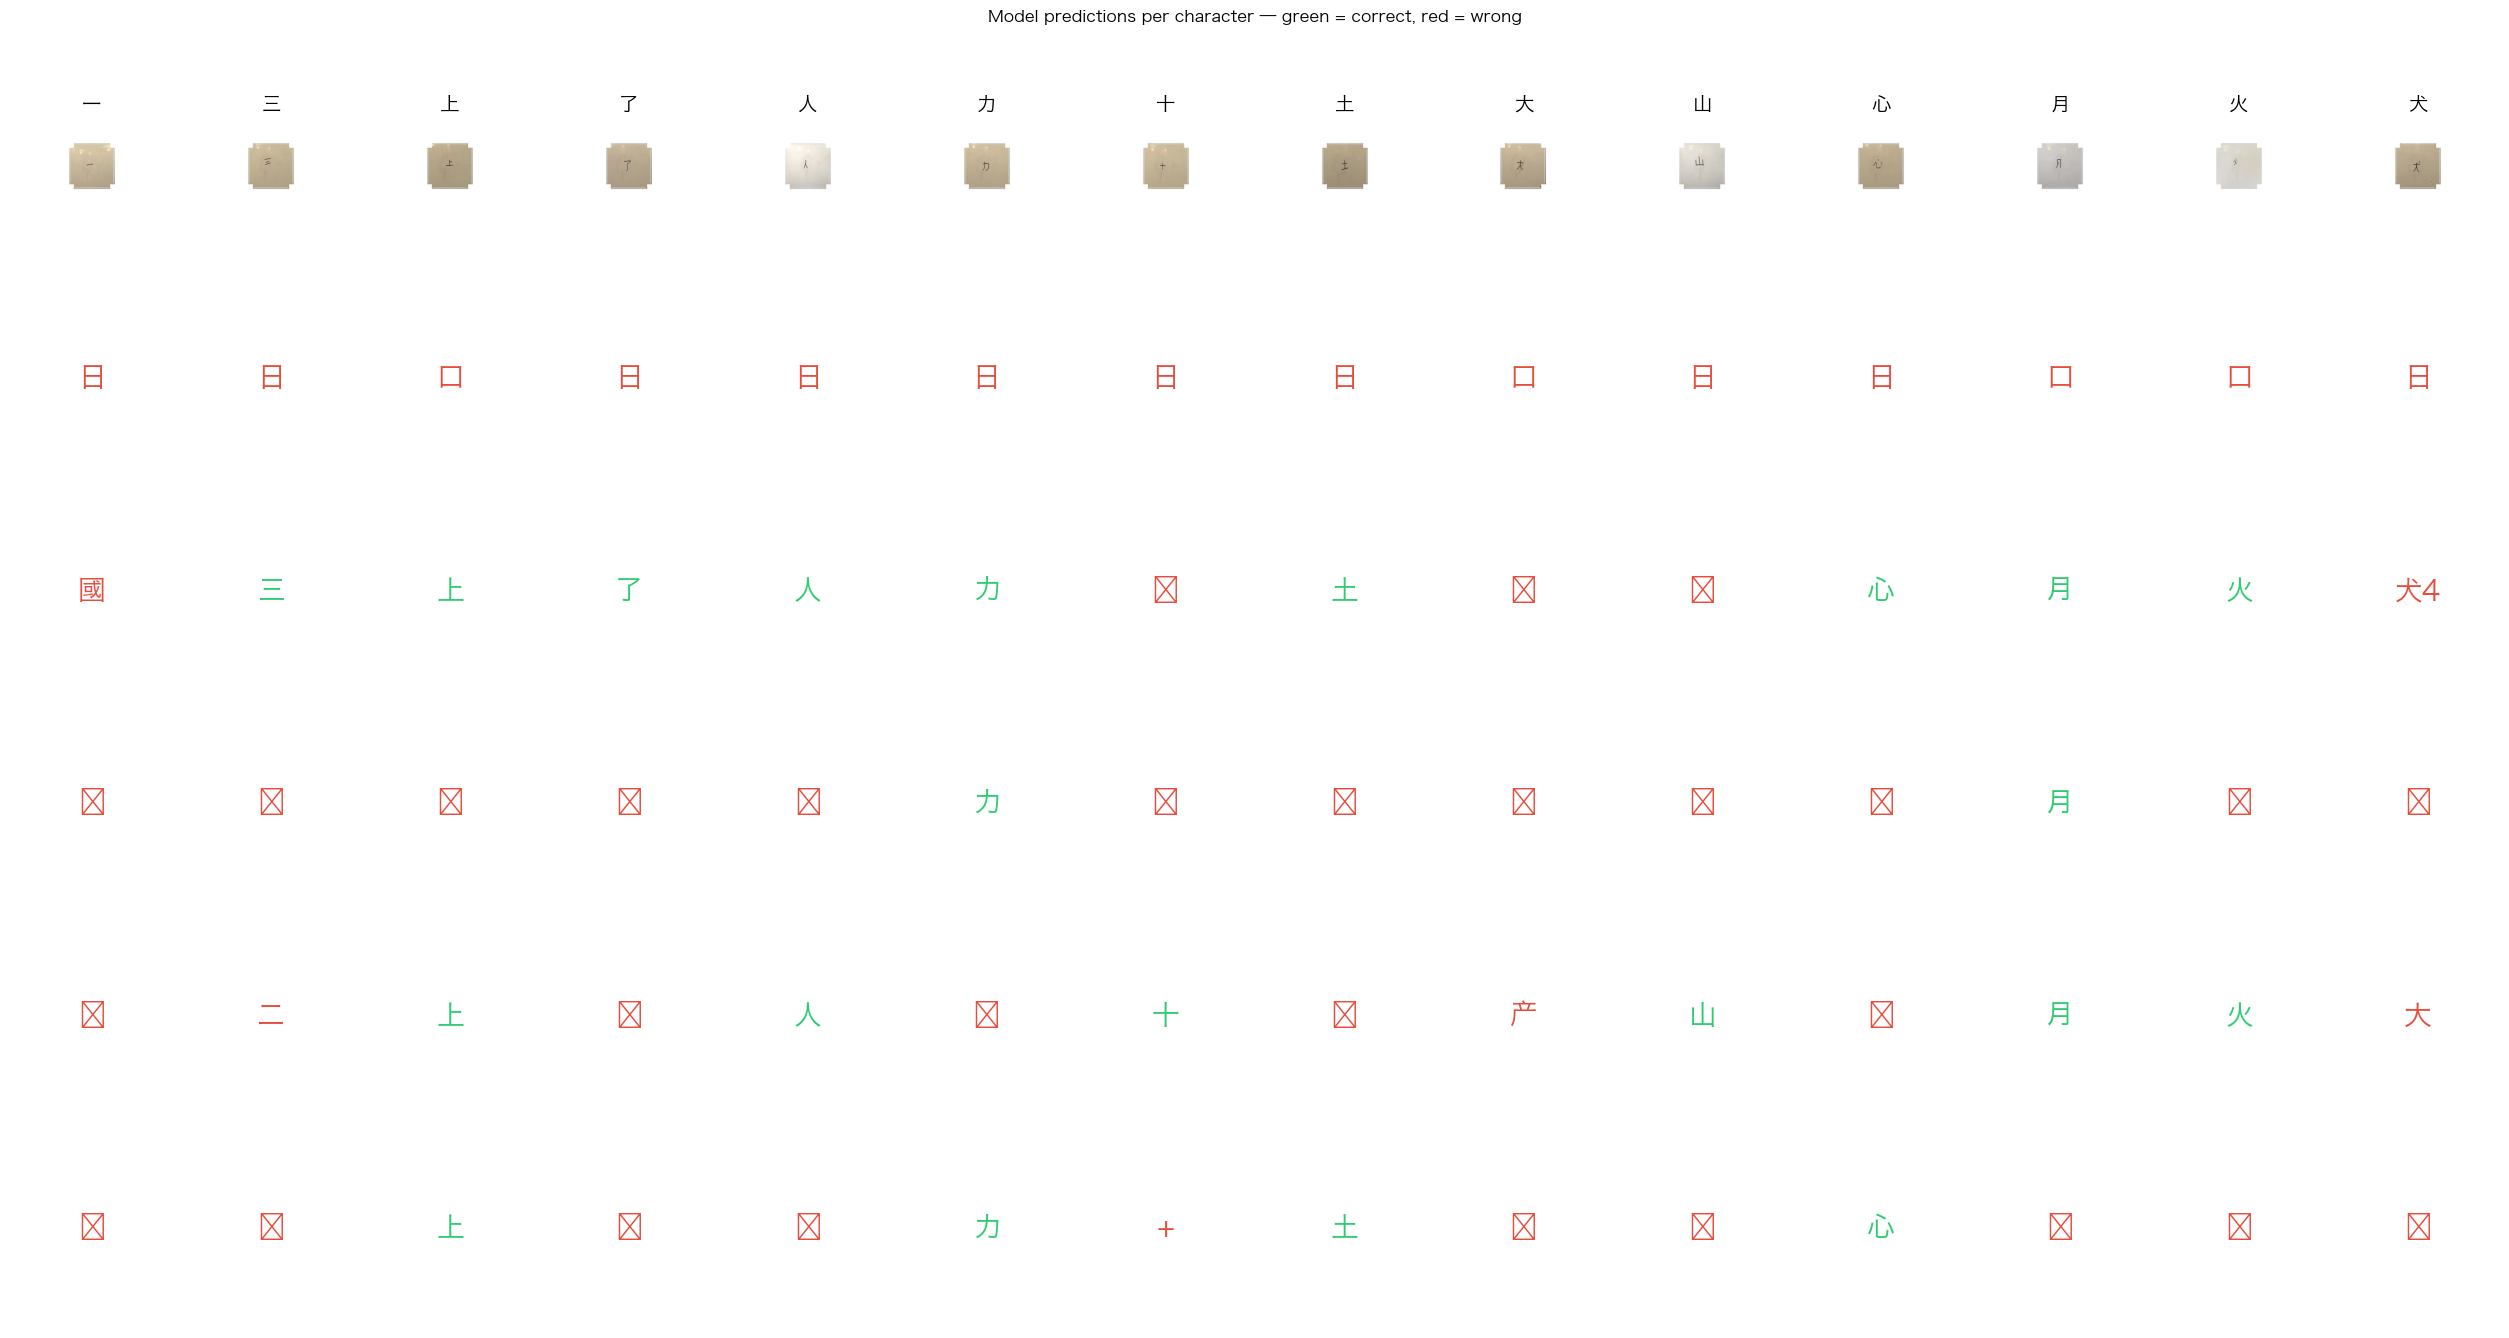

In [22]:
model_names = list(preds.keys())

# Pick first image of each character (most representative single sample)
sample_indices = [next(i for i, l in enumerate(labels) if l == c) for c in all_chars]

n_cols = len(all_chars)
n_rows = len(model_names) + 1  # +1 for image row

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 1.8, n_rows * 2.2))

for col, (char, idx) in enumerate(zip(all_chars, sample_indices)):
    # Top row: image
    axes[0, col].imshow(images[idx])
    axes[0, col].set_title(char, fontsize=14, fontweight="bold")
    axes[0, col].axis("off")

    # Remaining rows: each model's prediction
    for row, name in enumerate(model_names, start=1):
        pred_val = str(preds_arr[name][idx]).strip() or "∅"
        correct = pred_val == char
        color = "#2ecc71" if correct else "#e74c3c"
        axes[row, col].text(
            0.5, 0.5, pred_val,
            ha="center", va="center",
            fontsize=20, color=color, fontweight="bold",
            transform=axes[row, col].transAxes,
        )
        axes[row, col].set_facecolor("#f8f8f8")
        axes[row, col].axis("off")

# Row labels on left
axes[0, 0].set_ylabel("Image", fontsize=9, rotation=0, labelpad=40, va="center")
for row, name in enumerate(model_names, start=1):
    axes[row, 0].set_ylabel(name, fontsize=8, rotation=0, labelpad=50, va="center")

fig.suptitle(
    "Model predictions per character — green = correct, red = wrong",
    fontsize=12, fontweight="bold", y=1.01,
)
plt.tight_layout()
plt.savefig(f"{OUT_DIR}/vr_fig_predictions_grid.png", dpi=150, bbox_inches="tight")
plt.show()